In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install pymc numpyro jax jaxlib

In [3]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder

# Data Loading and Preprocessing

In [4]:
filepath = "/content/drive/MyDrive/Bayesian Mushroom Classification/mushrooms.csv"

mushroom_df = pd.read_csv(filepath)

mushroom_df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [5]:
def class_label(row):
  if row['class'] == 'e':
    return 0
  else:
    return 1

mushroom_df['poisonous'] = mushroom_df.apply(class_label, axis = 1)

In [6]:
features = ['cap-surface', 'gill-color', 'odor', 'ring-number',
            'spore-print-color', 'stalk-surface-above-ring',
            'veil-color']

In [7]:
oe = OrdinalEncoder()
mushroom_df[features] = oe.fit_transform(mushroom_df[features])

In [8]:
le = LabelEncoder()
y = le.fit_transform(mushroom_df['poisonous'])

# Mathematical Model & NIMBLE Analysis

In [9]:
with pm.Model() as mushroom_model:
  beta_0 = pm.Normal('beta_0', mu = 0 , sigma = 5)
  beta_cap = pm.Normal('beta_cap', mu = 0, sigma = 5)
  beta_gill = pm.Normal('beta_gill', mu = 0, sigma = 5)
  beta_odor = pm.Normal('beta_odor', mu = 0, sigma = 5)
  beta_ring = pm.Normal('beta_ring', mu = 0, sigma = 5)
  beta_spore = pm.Normal('beta_spore', mu = 0, sigma = 5)
  beta_stalk = pm.Normal('beta_stalk', mu = 0, sigma = 5)
  beta_veil = pm.Normal('beta_veil', mu = 0, sigma = 5)

  sigma_habitat = pm.HalfNormal('sigma_habitat', sigma = 5)
  beta_grasses = pm.Normal('beta_grasses', mu = 0, sigma = 1) * sigma_habitat
  beta_paths = pm.Normal('beta_paths', mu = 0, sigma = 1) * sigma_habitat
  beta_leaves = pm.Normal('beta_leaves', mu = 0, sigma = 1) * sigma_habitat
  beta_meadows = pm.Normal('beta_meadows', mu = 0, sigma = 1) * sigma_habitat
  beta_urban = pm.Normal('beta_urban', mu = 0, sigma = 1) * sigma_habitat
  beta_waste = pm.Normal('beta_waste', mu = 0, sigma = 1) * sigma_habitat
  beta_woods = pm.Normal('beta_woods', mu = 0, sigma = 1) * sigma_habitat

  is_grasses = (mushroom_df['habitat'] == 'g').astype(int).values
  is_paths = (mushroom_df['habitat'] == 'p').astype(int).values
  is_leaves = (mushroom_df['habitat'] == 'l').astype(int).values
  is_meadows = (mushroom_df['habitat'] == 'm').astype(int).values
  is_urban = (mushroom_df['habitat'] == 'u').astype(int).values
  is_waste = (mushroom_df['habitat'] == 'w').astype(int).values
  is_woods = (mushroom_df['habitat'] == 'd').astype(int).values

  linear_predictor = (beta_0 + beta_cap * mushroom_df['cap-surface'] +
                      beta_gill * mushroom_df['gill-color'] +
                      beta_odor * mushroom_df['odor'] +
                      beta_ring * mushroom_df['ring-number'] +
                      beta_spore * mushroom_df['spore-print-color'] +
                      beta_stalk * mushroom_df['stalk-surface-above-ring'] +
                      beta_veil * mushroom_df['veil-color'] +
                       (beta_grasses  * is_grasses) +
                      (beta_paths * is_paths) +
                       (beta_leaves * is_leaves) +
                      (beta_meadows * is_meadows) +
                       (beta_urban * is_urban) +
                      (beta_waste * is_waste) +
                       (beta_woods * is_woods))

  p = pm.math.invlogit(linear_predictor)
  y_obs = pm.Bernoulli('y_obs', p = p, observed = y)

  trace = pm.sample(draws = 500,
                    tune = 250,
                    chains = 3,
                    return_inferencedata = True,
                    nuts_sampler = 'numpyro')


/usr/local/lib/python3.12/dist-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 3 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(3)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(
sample: 100%|██████████| 750/750 [06:00<00:00,  2.08it/s, 511 steps of size 8.86e-03. acc. prob=0.95]
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


# Model Evaluation

Generating Trace and Density Plots


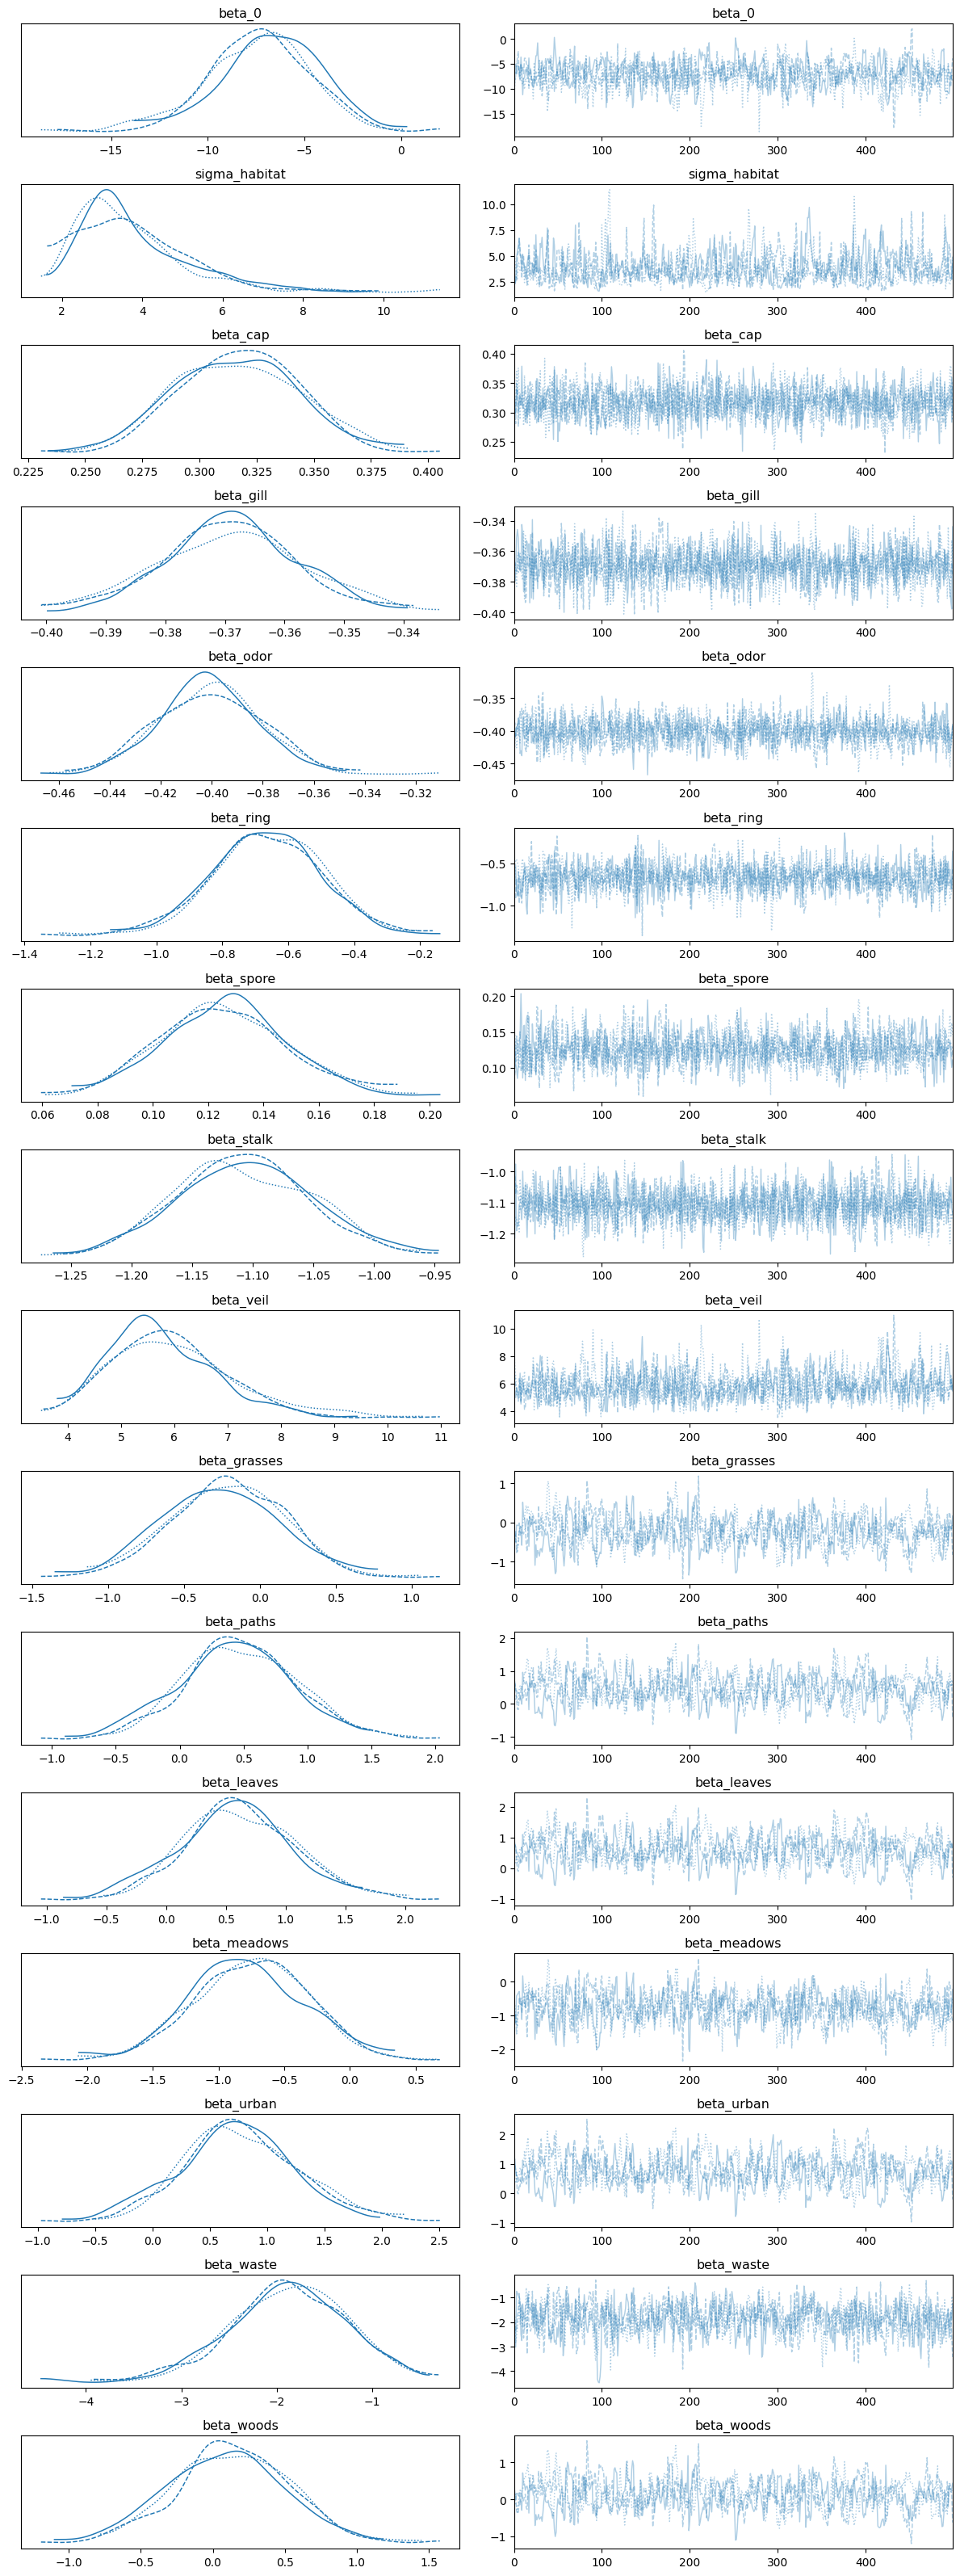

In [10]:
print("Generating Trace and Density Plots")
az.plot_trace(trace, var_names = ['beta_0', 'sigma_habitat',
                                  'beta_cap', 'beta_gill', 'beta_odor',
                                  'beta_ring', 'beta_spore', 'beta_stalk', 'beta_veil',
                                  'beta_grasses', 'beta_paths', 'beta_leaves', 'beta_meadows',
                                  'beta_urban', 'beta_waste', 'beta_woods'])
plt.tight_layout()
plt.show()

In [11]:
# check Gelman-Rubin Diagnostic
summary_stats = az.summary(trace, var_names = ['beta_0', 'sigma_habitat',
                                               'beta_cap', 'beta_gill', 'beta_odor',
                                               'beta_ring', 'beta_spore', 'beta_stalk', 'beta_veil',
                                               'beta_grasses', 'beta_paths', 'beta_leaves', 'beta_meadows',
                                               'beta_urban', 'beta_waste', 'beta_woods'])
print(summary_stats[['mean', 'sd', 'r_hat', 'ess_bulk']])

                mean     sd  r_hat  ess_bulk
beta_0        -7.141  2.637   1.01     534.0
sigma_habitat  3.771  1.419   1.00     377.0
beta_cap       0.317  0.027   1.00    1719.0
beta_gill     -0.369  0.012   1.01    2421.0
beta_odor     -0.401  0.020   1.00    1449.0
beta_ring     -0.664  0.165   1.00    1726.0
beta_spore     0.126  0.023   1.00    1566.0
beta_stalk    -1.107  0.056   1.00    2243.0
beta_veil      5.894  1.100   1.01     859.0
beta_grasses  -0.225  0.388   1.01     342.0
beta_paths     0.462  0.440   1.01     286.0
beta_leaves    0.606  0.467   1.01     279.0
beta_meadows  -0.765  0.439   1.00     397.0
beta_urban     0.759  0.496   1.01     281.0
beta_waste    -1.875  0.617   1.00     643.0
beta_woods     0.125  0.398   1.01     303.0


/usr/local/lib/python3.12/dist-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (48) in plot_autocorr, generating only 40 plots
  warnings.warn(


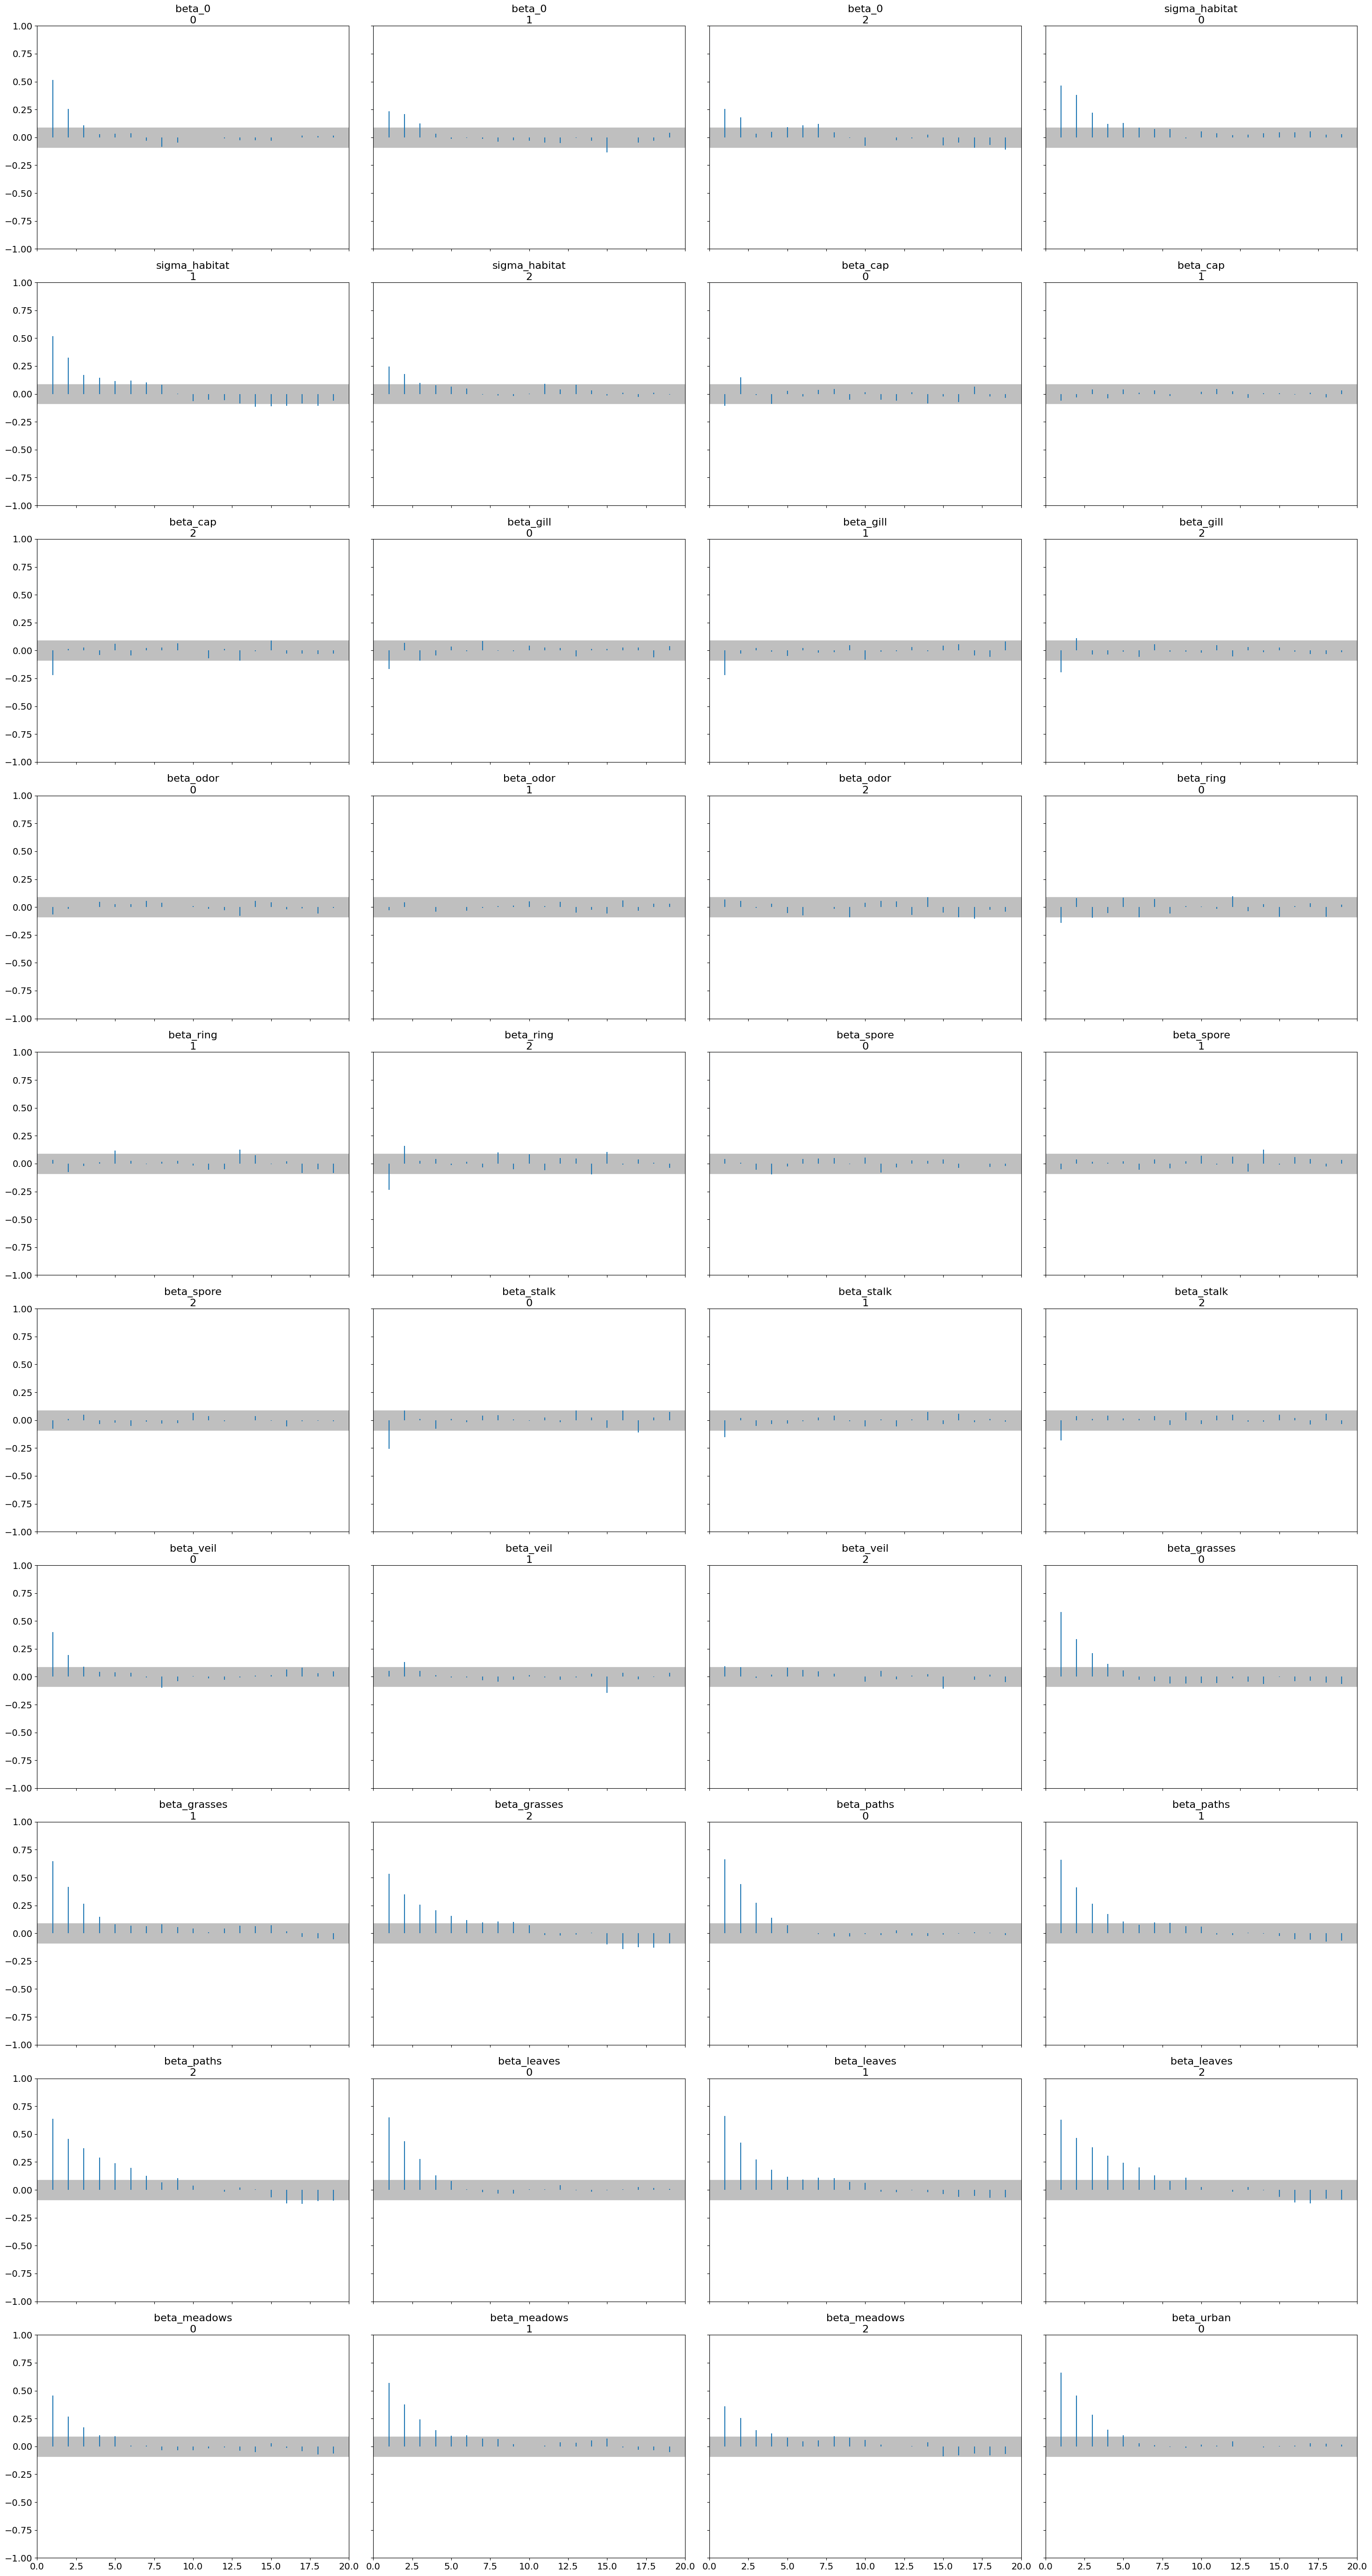

In [12]:
# check for the high autocorrelation
az.plot_autocorr(trace, var_names = ['beta_0', 'sigma_habitat',
                                      'beta_cap', 'beta_gill', 'beta_odor',
                                      'beta_ring', 'beta_spore', 'beta_stalk', 'beta_veil',
                                      'beta_grasses', 'beta_paths', 'beta_leaves', 'beta_meadows',
                                      'beta_urban', 'beta_waste', 'beta_woods'], max_lag = 20);
plt.tight_layout()
plt.show()

# Posterior Predictive Checks

In [13]:
with mushroom_model:
  posterior_predictive = pm.sample_posterior_predictive(trace)

Output()

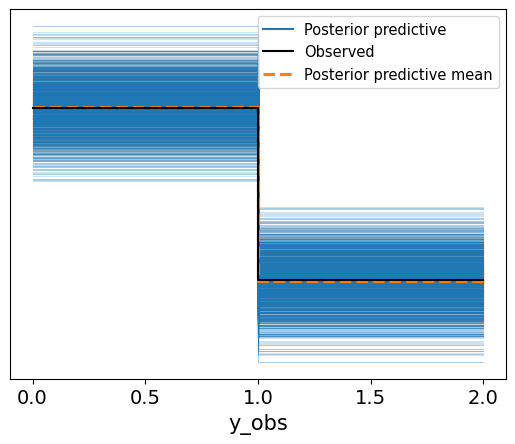

In [14]:
az.plot_ppc(posterior_predictive, kind = "kde")
plt.show()

In [15]:
clean_features = summary_stats.drop(['beta_0', 'sigma_habitat'], errors='ignore')
odds_ratios = np.exp(clean_features['mean'])

poster_table = pd.DataFrame({
    'Log-Odds (Beta)': clean_features['mean'],
    'Odds Ratio': odds_ratios})
print(poster_table)

              Log-Odds (Beta)  Odds Ratio
beta_cap                0.317    1.373003
beta_gill              -0.369    0.691425
beta_odor              -0.401    0.669650
beta_ring              -0.664    0.514788
beta_spore              0.126    1.134282
beta_stalk             -1.107    0.330549
beta_veil               5.894  362.853801
beta_grasses           -0.225    0.798516
beta_paths              0.462    1.587245
beta_leaves             0.606    1.833084
beta_meadows           -0.765    0.465334
beta_urban              0.759    2.136139
beta_waste             -1.875    0.153355
beta_woods              0.125    1.133148
